In [37]:
from PIL import Image 
import cv2
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

In [13]:
import os

path = r'D:\Projects\Assignment\Courses\CS231-ICV\HoaVietNam2026\HoaVietNam2026'
train_path = r'D:\Projects\Assignment\Courses\CS231-ICV\HoaVietNam2026\HoaVietNam2026\train'
os.listdir(train_path)

['Cuc', 'Dao', 'Ga', 'Lan', 'Mai', 'Sen', 'Tho']

In [3]:
path_train_cuc = os.path.join(train_path , 'Cuc')

images = []

for file_name in os.listdir(path_train_cuc):
    src = os.path.join(path_train_cuc , file_name)

    img = cv2.imread(src)

    if img is None:
        continue

    img = cv2.resize(img , (224,224))

    images.append(img)

    print(file_name, img.shape)

0001.jpg (224, 224, 3)
0002.jpg (224, 224, 3)
0003.jpg (224, 224, 3)
0004.jpg (224, 224, 3)
0005.jpg (224, 224, 3)
0006.jpg (224, 224, 3)
0007.jpg (224, 224, 3)
0008.jpg (224, 224, 3)
0009.jpg (224, 224, 3)
0010.jpg (224, 224, 3)
0011.jpg (224, 224, 3)
0012.jpg (224, 224, 3)
0013.jpg (224, 224, 3)
0014.jpg (224, 224, 3)
0015.jpg (224, 224, 3)
0016.jpg (224, 224, 3)
0017.jpg (224, 224, 3)
0018.jpg (224, 224, 3)
0019.jpg (224, 224, 3)
0020.jpg (224, 224, 3)
0021.jpg (224, 224, 3)
0022.jpg (224, 224, 3)
0023.jpg (224, 224, 3)
0024.jpg (224, 224, 3)
0025.jpg (224, 224, 3)
0026.jpg (224, 224, 3)
0027.jpg (224, 224, 3)
0029.jpg (224, 224, 3)
0030.jpg (224, 224, 3)
0031.jpg (224, 224, 3)
0032.jpg (224, 224, 3)
0033.jpg (224, 224, 3)
0034.jpg (224, 224, 3)
0035.jpg (224, 224, 3)
0036.jpg (224, 224, 3)
0037.jpg (224, 224, 3)
0038.jpg (224, 224, 3)
0039.jpg (224, 224, 3)
0040.jpg (224, 224, 3)
028.jpg (224, 224, 3)


40
(40, 224, 224, 3)
AxesImage(shape=(224, 224, 3))


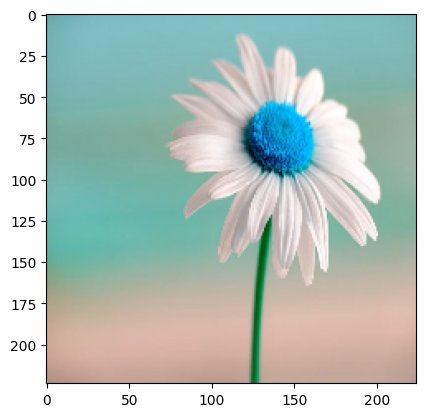

In [5]:
print(len(images))

X = np.array(images)

print(X.shape)
print(plt.imshow(X[0]))

In [22]:
r , g , b = cv2.split(X[0])

In [30]:
compare = lambda a , b : (a-b)**2

In [31]:
a = cv2.calcHist(images=[r] , channels=[0] , mask= None , histSize=[256],ranges= [0 , 256])
b = cv2.calcHist(images=[X[0]] , channels=[0] , mask= None , histSize=[256],ranges= [0 , 256])
print(compare(a ,b))

[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.

In [63]:
def extract_normal_hist(img):
    
    r , g , b = cv2.split(img)

    hist_r = cv2.calcHist([r] , [0] , None , [256] , [0 , 256])
    hist_g = cv2.calcHist([g] , [0] , None , [256] , [0 , 256])
    hist_b = cv2.calcHist([b] , [0] , None , [256] , [0 , 256])

    hist_r /=  hist_r.sum()   
    hist_b /=  hist_b.sum() 
    hist_g /=  hist_g.sum() 

    feature = np.concatenate([hist_r , hist_b , hist_b]).flatten()

    return feature

In [60]:
def extract_hsv_histogram(image):

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    hist = cv2.calcHist(
        [hsv],
        [0,1,2],
        None,
        [8,8,8],
        [0,180,0,256,0,256]
    )

    hist = cv2.normalize(hist, hist).flatten()

    return hist

In [76]:
def extract_color_moments(image):

    moments = []

    for channel in cv2.split(image):

        mean = np.mean(channel)
        std = np.std(channel)
        skew = np.cbrt(np.mean((channel - mean)**3))

        moments.extend([mean, std, skew])

    return np.array(moments)

In [62]:
from sklearn.cluster import KMeans

def extract_dominant_color(image):

    pixels = image.reshape((-1,3))

    kmeans = KMeans(n_clusters=3)

    kmeans.fit(pixels)

    colors = kmeans.cluster_centers_

    return colors.flatten()

# Bai 1 
Áp dụng Bộ phân lớp KNeighborsClassifier để thực hiện phân loại. Hãy xác định giá trị của các tham số sao cho Độ chính xác cao nhất:

Sử dụng đặc trưng về màu sắc:
- Histogram với 3 thành phần màu RGB
- Sử dụng 256 bin cho mỗi thành phần màu
- Tính histogram riêng từng thành phần


In [80]:
flo_names = ['Cuc', 'Dao', 'Ga', 'Lan', 'Mai', 'Sen', 'Tho']
name_to_num = {name :  i for i , name  in enumerate(flo_names)}

def creat_dataset(type : str = 'train', extractor_namme : str = 'normal_hist', return_img = False):

    type_path = os.path.join(path, type)

    features = []
    labels = []
    images = []

    print(f"XU LY TAP {type}")

    print("="* 50)

    for name in flo_names:
        print(f"Dang xu li folder {name}")
        for file_name in os.listdir(os.path.join(type_path , name)):
            
            src = os.path.join(type_path , name , file_name)

            img = cv2.imread(src)

            if img is None:
                continue
            
            if extractor_namme == 'normal_hist':
                feature = extract_normal_hist(img)
            elif extractor_namme == 'hssv_hist': 
                feature = extract_hsv_histogram(img)
            elif extractor_namme == 'color_moments':
                feature = extract_color_moments(img)
            else:
                feature = extract_dominant_color(img)

            features.append(feature)
            labels.append(name_to_num[name])
            images.append(img)
                
    if return_img == True:
        return features , labels , images
    return features , labels

In [81]:
X_train, y_train = creat_dataset("train")
X_test , y_test = creat_dataset("test")

print("=" * 50)
print(len(X_train))
print(len(y_train))
print(len(X_test))
print(len(y_test))
print(f"Shape = {X_train[0].shape}")

XU LY TAP train
Dang xu li folder Cuc
Dang xu li folder Dao
Dang xu li folder Ga
Dang xu li folder Lan
Dang xu li folder Mai
Dang xu li folder Sen
Dang xu li folder Tho
XU LY TAP test
Dang xu li folder Cuc
Dang xu li folder Dao
Dang xu li folder Ga
Dang xu li folder Lan
Dang xu li folder Mai
Dang xu li folder Sen
Dang xu li folder Tho
249
249
77
77
Shape = (768,)


In [65]:
X_train = np.array(X_train)
y_train = np.array(y_train)

indices = np.arange(len(X_train))
np.random.shuffle(indices)

X_train = X_train[indices]
y_train = y_train[indices]

In [66]:

estimator = KNeighborsClassifier()

param_grid = {
    'n_neighbors' : range(1, 11),
    'weights' : ['uniform' , 'distance'],
    'metric' : ['braycurtis' , 'canberra' , 'correlation' , 'cosine', 'euclidean' , 'minkowski']
}

grid_search = GridSearchCV(estimator=estimator, param_grid= param_grid , cv = 5 , verbose= 1 , scoring ='accuracy')
print(grid_search)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['braycurtis', 'canberra', 'correlation',
                                    'cosine', 'euclidean', 'minkowski'],
                         'n_neighbors': range(1, 11),
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=1)


In [67]:
grid_search.fit(X_train , y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['braycurtis', 'canberra', ...], 'n_neighbors': range(1, 11), 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is d

In [68]:
y_pred = grid_search.predict(X_test)

print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.57      0.80      0.67        10
           1       0.53      0.67      0.59        12
           2       0.60      0.60      0.60        15
           3       0.83      0.50      0.62        10
           4       1.00      0.10      0.18        10
           5       0.38      0.30      0.33        10
           6       0.44      0.80      0.57        10

    accuracy                           0.55        77
   macro avg       0.62      0.54      0.51        77
weighted avg       0.62      0.55      0.52        77




# Bai 2 

Từ các giá trị tham số tối ưu. Hãy thực nghiệm so sánh độ chính xác khi sử dụng đặc trưng về màu sắc:
- Histogram với 3 thành phần màu HSV tương ứng 8x8x8
- Moment màu
- Màu chủ đạo


In [70]:
best_classifier = grid_search.best_estimator_
print(best_classifier)

KNeighborsClassifier(metric='canberra', weights='distance')


## HSV

In [72]:
X_train, y_train = creat_dataset("train" , 'hssv_hist')
X_test , y_test = creat_dataset("test" , 'hssv_hist')


best_classifier.fit(X_train , y_train)
y_pred = best_classifier.predict(X_test)

print(classification_report(y_test , y_pred))

XU LY TAP train
Dang xu li folder Cuc
Dang xu li folder Dao
Dang xu li folder Ga
Dang xu li folder Lan
Dang xu li folder Mai
Dang xu li folder Sen
Dang xu li folder Tho
XU LY TAP test
Dang xu li folder Cuc
Dang xu li folder Dao
Dang xu li folder Ga
Dang xu li folder Lan
Dang xu li folder Mai
Dang xu li folder Sen
Dang xu li folder Tho
              precision    recall  f1-score   support

           0       0.53      0.90      0.67        10
           1       0.67      0.83      0.74        12
           2       0.89      0.53      0.67        15
           3       0.88      0.70      0.78        10
           4       0.62      0.80      0.70        10
           5       1.00      0.40      0.57        10
           6       0.55      0.60      0.57        10

    accuracy                           0.68        77
   macro avg       0.73      0.68      0.67        77
weighted avg       0.74      0.68      0.67        77



## Color moment

In [77]:
X_train, y_train = creat_dataset("train" , 'color_moments')
X_test , y_test = creat_dataset("test" , 'color_moments')


best_classifier.fit(X_train , y_train)
y_pred = best_classifier.predict(X_test)

print(classification_report(y_test , y_pred))

XU LY TAP train
Dang xu li folder Cuc
Dang xu li folder Dao
Dang xu li folder Ga
Dang xu li folder Lan
Dang xu li folder Mai
Dang xu li folder Sen
Dang xu li folder Tho
XU LY TAP test
Dang xu li folder Cuc
Dang xu li folder Dao
Dang xu li folder Ga
Dang xu li folder Lan
Dang xu li folder Mai
Dang xu li folder Sen
Dang xu li folder Tho
              precision    recall  f1-score   support

           0       0.53      0.90      0.67        10
           1       0.47      0.75      0.58        12
           2       0.67      0.53      0.59        15
           3       0.25      0.10      0.14        10
           4       0.50      0.50      0.50        10
           5       0.67      0.40      0.50        10
           6       0.67      0.60      0.63        10

    accuracy                           0.55        77
   macro avg       0.54      0.54      0.52        77
weighted avg       0.54      0.55      0.52        77



## Dominant color

In [78]:
X_train, y_train = creat_dataset("train" , 'dominant_color')
X_test , y_test = creat_dataset("test" , 'dominant_color')


best_classifier.fit(X_train , y_train)
y_pred = best_classifier.predict(X_test)

print(classification_report(y_test , y_pred))

XU LY TAP train
Dang xu li folder Cuc
Dang xu li folder Dao
Dang xu li folder Ga
Dang xu li folder Lan
Dang xu li folder Mai
Dang xu li folder Sen
Dang xu li folder Tho
XU LY TAP test
Dang xu li folder Cuc
Dang xu li folder Dao
Dang xu li folder Ga
Dang xu li folder Lan
Dang xu li folder Mai
Dang xu li folder Sen
Dang xu li folder Tho
              precision    recall  f1-score   support

           0       0.35      0.80      0.48        10
           1       0.59      0.83      0.69        12
           2       0.55      0.40      0.46        15
           3       0.75      0.30      0.43        10
           4       0.30      0.30      0.30        10
           5       0.33      0.10      0.15        10
           6       0.44      0.40      0.42        10

    accuracy                           0.45        77
   macro avg       0.47      0.45      0.42        77
weighted avg       0.48      0.45      0.43        77



# Bai 3

Sử dụng các giá trị tham tối ưu như trong yêu cầu 1. 

Giả sử gọi A là trường hợp sử dụng: Histogram với 3 thành phần màu RGB

Giả sử gọi B là trường hợp sử dụng: Histogram với 3 thành phần màu HSV tương ứng 16x16x16

Hãy in ra danh sách các ảnh trong tập test mà trong trường hợp:

- A: sai nhưng B: đúng  minh họa ưu điểm của B
- A: đúng nhưng B: sai   minh họa ưu điểm của A
- A: sai và B: sai   minh họa những mẫu khó



In [104]:
X_train_normal_hist , y_train_normal_hist = creat_dataset('train')
X_test_normal_hist , y_test_normal_hist , images = creat_dataset('test', return_img= True)

X_train_hssv_hist , y_train_hssv_hist = creat_dataset('train', 'hssv_hist')
X_test_hssv_hist , y_test_hssv_hist = creat_dataset('test' , 'hssv_hist')

XU LY TAP train
Dang xu li folder Cuc
Dang xu li folder Dao
Dang xu li folder Ga
Dang xu li folder Lan
Dang xu li folder Mai
Dang xu li folder Sen
Dang xu li folder Tho
XU LY TAP test
Dang xu li folder Cuc
Dang xu li folder Dao
Dang xu li folder Ga
Dang xu li folder Lan
Dang xu li folder Mai
Dang xu li folder Sen
Dang xu li folder Tho
XU LY TAP train
Dang xu li folder Cuc
Dang xu li folder Dao
Dang xu li folder Ga
Dang xu li folder Lan
Dang xu li folder Mai
Dang xu li folder Sen
Dang xu li folder Tho
XU LY TAP test
Dang xu li folder Cuc
Dang xu li folder Dao
Dang xu li folder Ga
Dang xu li folder Lan
Dang xu li folder Mai
Dang xu li folder Sen
Dang xu li folder Tho


##  A: sai nhưng B: đúng

In [82]:
best_classifier.fit(X_train_normal_hist, y_train_normal_hist)

y_pred_normal_hist = best_classifier.predict(X_test_normal_hist)

In [90]:
best_classifier.fit(X_train_hssv_hist, y_train_hssv_hist)

y_pred_hssv_hist = best_classifier.predict(X_test_hssv_hist)

In [101]:
a_wrong_indices = np.where(y_pred_normal_hist != y_test_normal_hist)[0]
b_true_indices = np.where(y_pred_hssv_hist == y_test_normal_hist)[0]

intersected_indices = list(set(a_wrong_indices) & set(b_true_indices))

In [106]:
np.random.choice(intersected_indices , 5)

array([57, 41, 57, 47, 27])

True label : 0
HSV predict label : 0
HIST predict label : 5


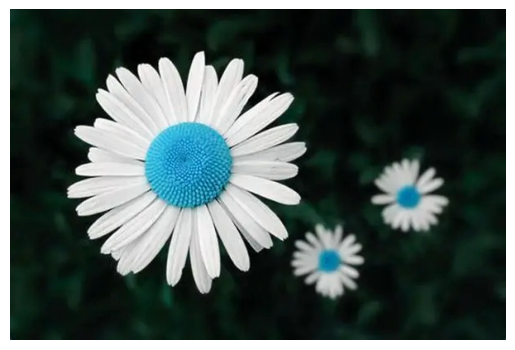

True label : 4
HSV predict label : 4
HIST predict label : 2


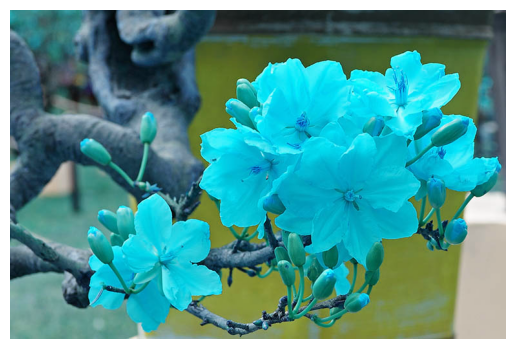

True label : 5
HSV predict label : 5
HIST predict label : 2


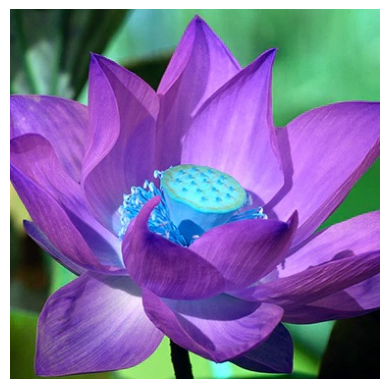

True label : 2
HSV predict label : 2
HIST predict label : 1


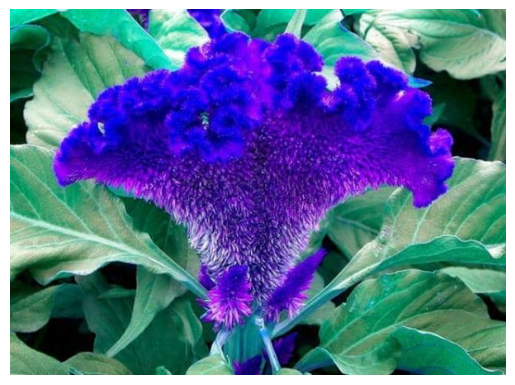

True label : 5
HSV predict label : 5
HIST predict label : 1


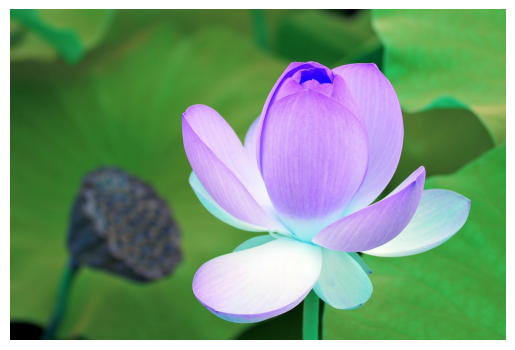

True label : 4
HSV predict label : 4
HIST predict label : 6


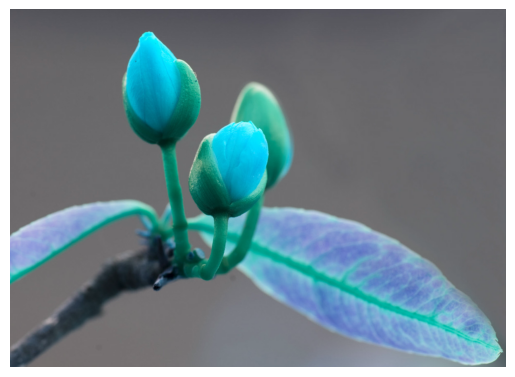

True label : 3
HSV predict label : 3
HIST predict label : 1


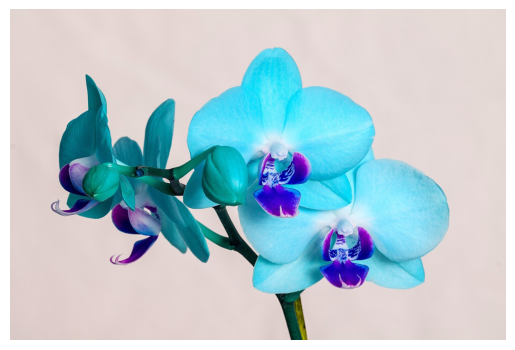

True label : 3
HSV predict label : 3
HIST predict label : 0


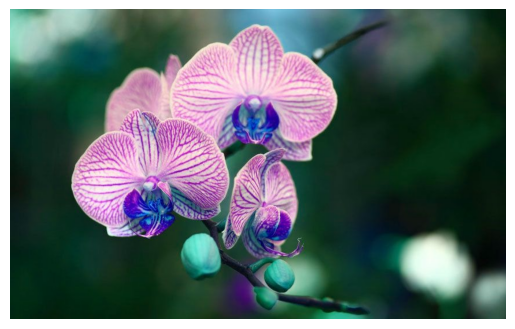

True label : 3
HSV predict label : 3
HIST predict label : 5


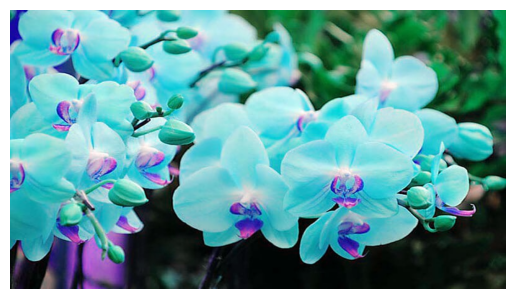

True label : 0
HSV predict label : 0
HIST predict label : 5


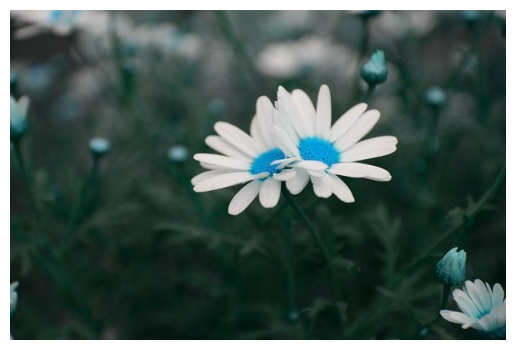

In [109]:
for i in np.random.choice(intersected_indices, 10, replace=False):

    print("="*50)
    print(f"True label : {y_test_hssv_hist[i]}")
    print(f"HSV predict label : {y_pred_hssv_hist[i]}")
    print(f"HIST predict label : {y_pred_normal_hist[i]}")

    plt.imshow(images[i])
    plt.axis("off")
    plt.show()